In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ic272_lab5_rent.csv")
features = [c for c in df.columns if c != "rent"]
X = df[features].to_numpy(float)
y = df["rent"].to_numpy(float)

idx = np.random.default_rng(0).permutation(len(y))
tr, te = idx[:40], idx[40:]
X_train, X_test = X[tr], X[te]
y_train, y_test = y[tr], y[te]

print("train:", X_train.shape, "test:", X_test.shape)

def design_matrix(X):
    return np.c_[np.ones(len(X)), X]

def fit_normal_equation(X, y):
    A = design_matrix(X)
    return np.linalg.solve(A.T @ A, A.T @ y)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

train: (40, 13) test: (260, 13)


In [2]:
df.head()

,area,rooms,age,dist_km,floors,noise_a,noise_b,noise_c,noise_d,noise_id,noise_tiny1,noise_tiny2,noise_tiny3,rent
0,6.95,1.0,2.07,3.37,3.0,-1.427,-3.949,3.565,0.942,102599.8,-0.04019,0.01533,-0.00664,49.43
1,6.60,1.0,4.16,2.75,3.0,3.250,-1.661,0.115,-0.641,104247.9,0.06649,-0.04765,0.01735,49.77
2,7.94,3.0,1.55,1.50,3.0,0.352,2.862,-2.141,1.424,104462.2,-0.04877,0.01032,0.02804,67.01
3,8.11,1.0,4.63,8.55,3.0,2.718,3.294,-0.588,-0.828,104208.2,0.05701,-0.03814,-0.07833,47.21
4,6.08,2.0,3.04,2.99,1.0,0.807,1.184,-1.173,-0.717,101090.7,-0.04293,0.00170,-0.00129,45.25


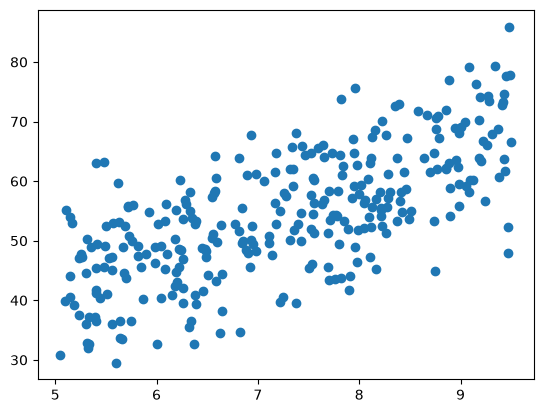

In [36]:
plt.scatter(df['area'],df['rent'])

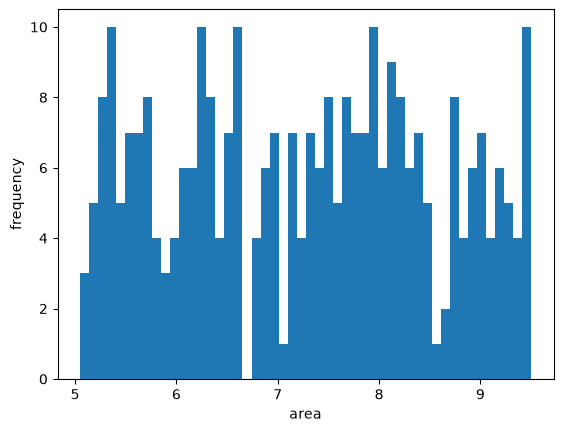

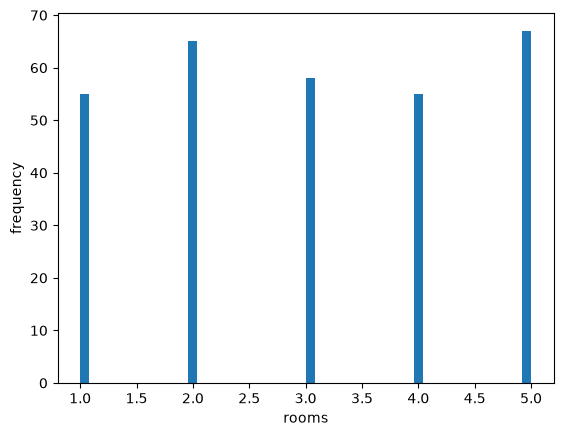

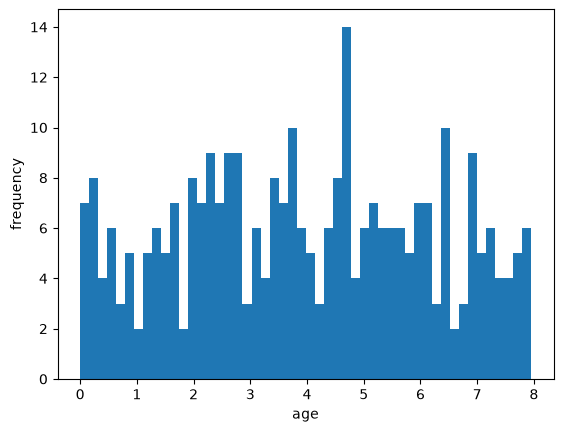

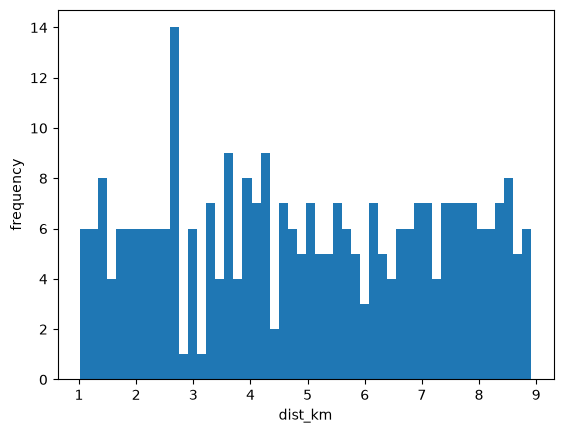

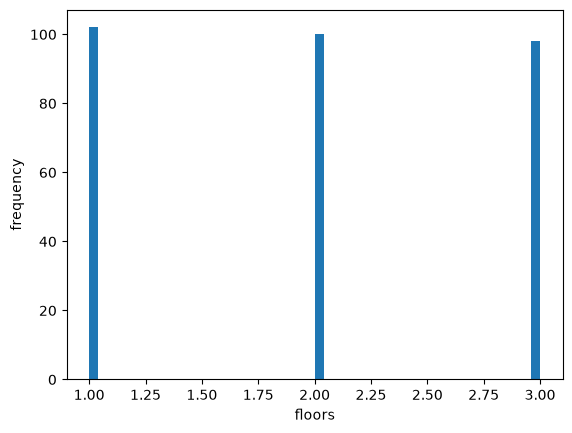

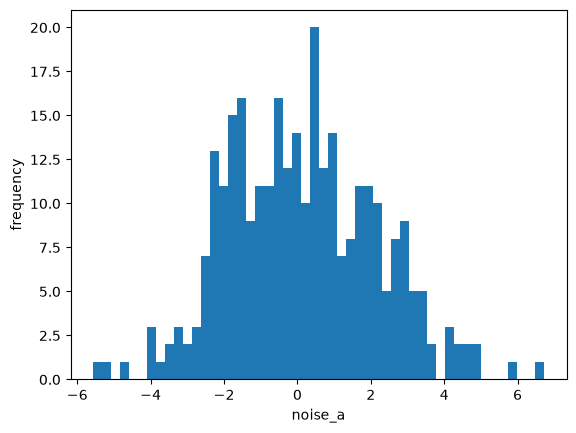

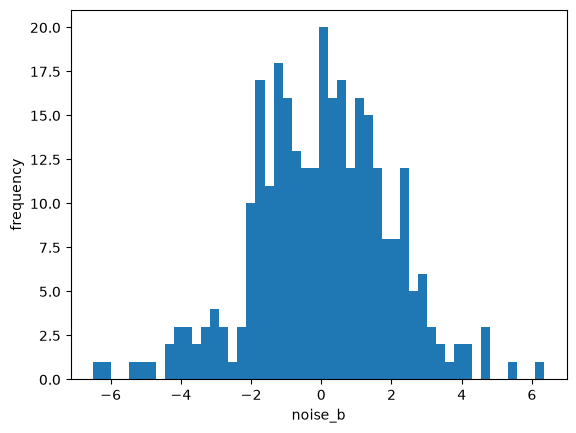

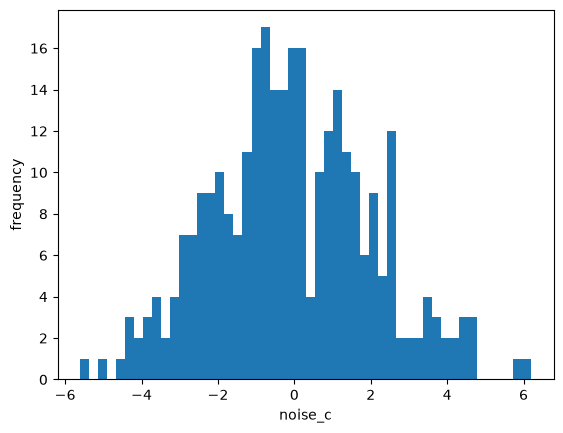

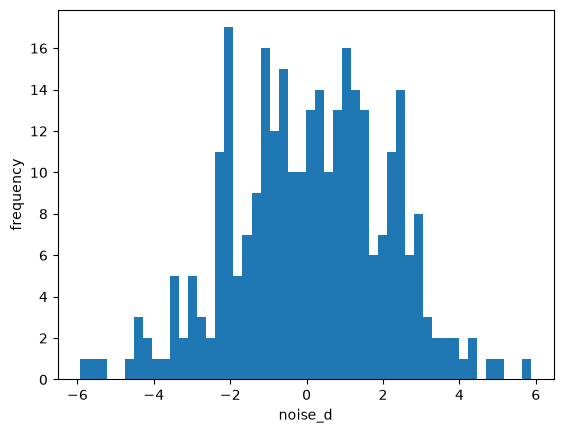

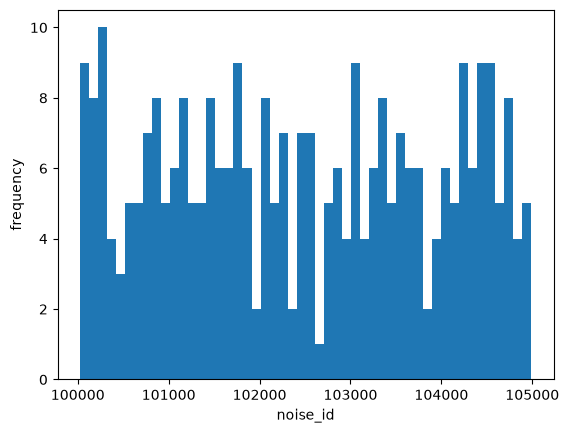

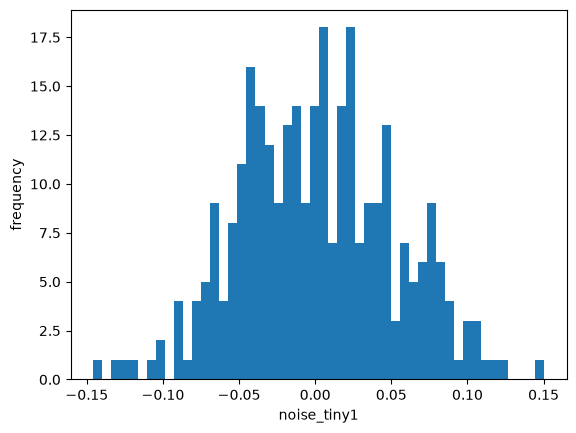

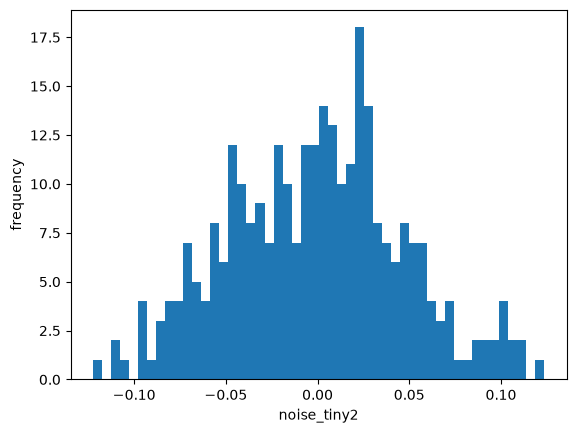

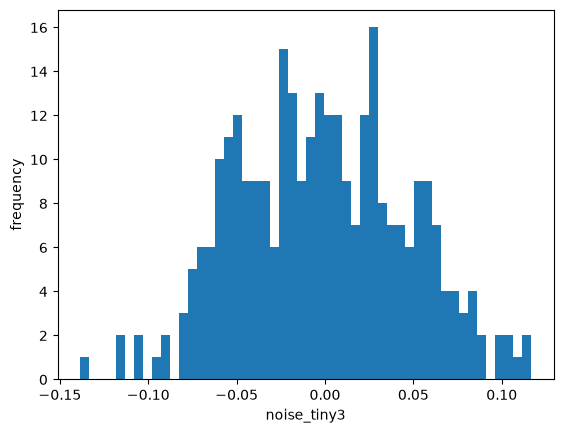

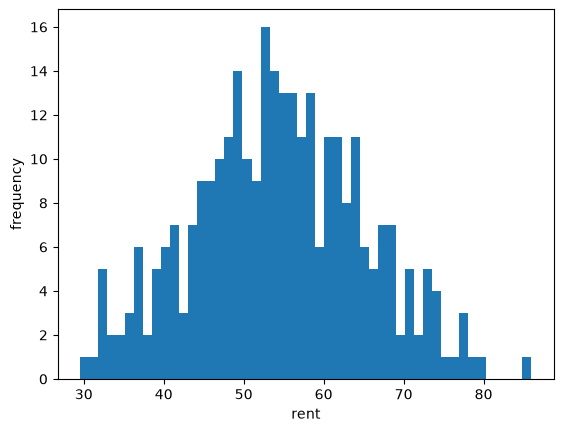

In [45]:
for i in df:
    plt.hist(df[i],bins=50)
    plt.ylabel("frequency")
    plt.xlabel(i)
    plt.show()

In [5]:
theta_raw=fit_normal_equation(X_train,y_train)
print(f"{'feature':14s}{'coefficient':>13}{'column sd':>12}")
for name, coef, s in zip(features, theta_raw[1:], X_train.std(axis=0)):
    print(f"{name:14s}{coef:13.4f}{s:12.4f}")

feature         coefficient   column sd
area                 6.2035      1.3899
rooms                3.5651      1.4239
age                 -1.4889      2.2148
dist_km             -2.1478      2.2604
floors               1.9149      0.8182
noise_a             -0.4443      2.0689
noise_b             -0.1819      2.3947
noise_c             -0.3990      2.0424
noise_d              0.1087      1.9085
noise_id            -0.0004   1620.1592
noise_tiny1        -11.2210      0.0563
noise_tiny2         -6.3696      0.0462
noise_tiny3        -11.9928      0.0526


In [46]:
def standardise(X_train, X_test):
    mu=X_train.mean(axis=0)
    sigma=X_train.std(axis=0)
    X_train_scaled=(X_train - mu)/sigma
    X_test_scaled=(X_test - mu)/sigma
    return X_train_scaled, X_test_scaled, mu, sigma

Z_train,Z_test,mu,sigma=standardise(X_train,X_test)

print("Per-column standard deviation of standardised training set:")
print(Z_train.std(axis=0))

print("\nPer-column standard deviation of standardised test set:")
print(Z_test.std(axis=0))

Per-column standard deviation of standardised training set:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Per-column standard deviation of standardised test set:
[0.90471265 0.99222493 0.98564    1.02481282 0.99700378 0.97260292
 0.78643272 1.0231371  1.06495137 0.89446554 0.885202   1.03412701
 0.8849837 ]


In [54]:
thetas=[]
def fit_ridge(X, y, lam):
    A=design_matrix(X)
    n_features =A.shape[1]
    penalty=lam*np.eye(n_features)
    penalty[0,0]=0  
    theta=np.linalg.solve(A.T @ A + penalty, A.T @ y)
    return theta

lambdas=[0,1,10,100,1000,10000,100000]
for lam in lambdas:
    theta = fit_ridge(Z_train, y_train, lam)
    print(theta)
    thetas.append(theta)
    zeros = np.sum(np.abs(theta[1:]) < 0.0000000000000000000000001)
    print(f"\nLambda: {lam} Exact zero coefficients - {zeros}")
    print('--------------------------------------------------')


[52.7675      8.62228061  5.07634651 -3.29768683 -4.85508405  1.56669972
 -0.91915016 -0.43569685 -0.81500814  0.20745268 -0.69211872 -0.63175355
 -0.29409296 -0.63062904]

Lambda: 0 Exact zero coefficients - 0
--------------------------------------------------
[52.7675      8.07360599  4.85154708 -3.06404228 -4.51372277  1.27840121
 -0.65920214 -0.65018018 -0.58940495  0.33535769 -0.62922629 -0.71269362
 -0.25309823 -0.36610874]

Lambda: 1 Exact zero coefficients - 0
--------------------------------------------------
[52.7675      5.57342379  3.54860721 -1.98802717 -2.96120009  0.19238397
  0.11802234 -1.30889107  0.19452634  0.8976363  -0.42652759 -0.94834877
 -0.17311282  0.56710226]

Lambda: 10 Exact zero coefficients - 0
--------------------------------------------------
[ 5.27675000e+01  1.88902560e+00  1.06651781e+00 -5.54281721e-01
 -8.36212761e-01 -2.73180240e-01  6.90061269e-03 -8.81867413e-01
  3.77486718e-01  8.23151396e-01 -1.64442623e-01 -4.72144148e-01
 -6.00127859e-02  

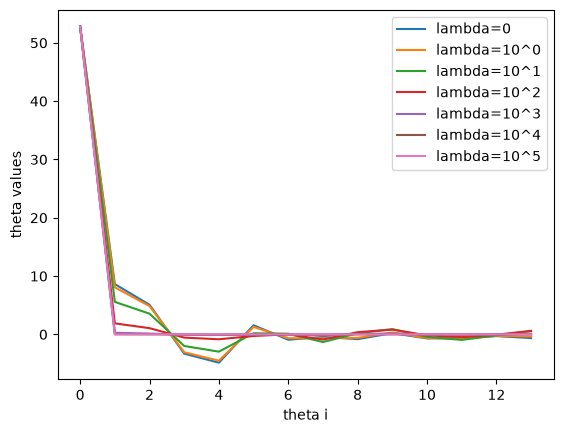

In [59]:
for i in range(len(thetas)):
    if i==0:
        plt.plot(thetas[i],label="lambda=0")
    else:
        plt.plot(thetas[i],label=f"lambda=10^{i-1}")
plt.xlabel("theta i")
plt.ylabel("theta values")
plt.legend()

        
    

In [27]:
def k_fold_cv(X_train_raw,y_train,lam,k=5,seed=0):
    n=len(y_train)
    idx=np.random.default_rng(seed).permutation(n)
    folds=np.array_split(idx,k)
    rmse_list=[]
    for i in range(k):
        val_idx=folds[i]
        train_idx=np.concatenate([folds[j] for j in range(k) if j != i])
        X_tr_raw,y_tr=X_train_raw[train_idx],y_train[train_idx]
        X_val_raw,y_val=X_train_raw[val_idx], y_train[val_idx]
        mu=X_tr_raw.mean(axis=0)
        sigma=X_tr_raw.std(axis=0)
        X_tr=(X_tr_raw-mu)/sigma
        X_val=(X_val_raw-mu)/sigma
        theta=fit_ridge(X_tr,y_tr,lam)
        y_pred=design_matrix(X_val) @ theta
        rmse_list.append(rmse(y_val,y_pred))
    return np.mean(rmse_list)

lam_grid=[0,0.1,0.3,1,3,10,30,100]
cv_results= {}
print(f"{'Lambda'} and {'CV RMSE'}")

for lam in lam_grid:
    cv_rmse = k_fold_cv(X_train, y_train, lam, k=5, seed=0)
    cv_results[lam] = cv_rmse
    print(f"{lam} and {cv_rmse}")
best_lam = min(cv_results, key=cv_results.get)
print(f"\nBest Lambda: {best_lam}")
theta_0=fit_ridge(Z_train, y_train, 0)
test_rmse_0 = rmse(y_test, design_matrix(Z_test) @ theta_0)
theta_best = fit_ridge(Z_train, y_train, best_lam)
test_rmse_best = rmse(y_test, design_matrix(Z_test) @ theta_best)
print(f"Test RMSE at lambda = 0: {test_rmse_0:.4f}")
print(f"Test RMSE at lambda = {best_lam}: {test_rmse_best:.4f}")

Lambda and CV RMSE
0 and 3.2686473721135734
0.1 and 3.2023556723285873
0.3 and 3.0963903368627905
1 and 2.9374611123529677
3 and 3.2387855396490153
10 and 4.638036877704316
30 and 6.404540882584404
100 and 8.206719746106232

Best Lambda: 1
Test RMSE at lambda = 0: 3.3430
Test RMSE at lambda = 1: 3.0857
